<a href="https://colab.research.google.com/github/s24118-ui/ASI/blob/main/Projekt_ASI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/ASI')

df = pd.read_csv('data.csv', sep=',')
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_8599/1797980452.py:10: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv', sep=',')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [6]:
print(f"Number of unique Customer_ID values: {df['Customer_ID'].nunique()}")
duplicate_customer_ids = df[df.duplicated(subset=['Customer_ID'], keep=False)]

Number of unique Customer_ID values: 12500


# Trzeba będzie grupować żeby ID klientów nie powtarzało się w obu grupach train / test

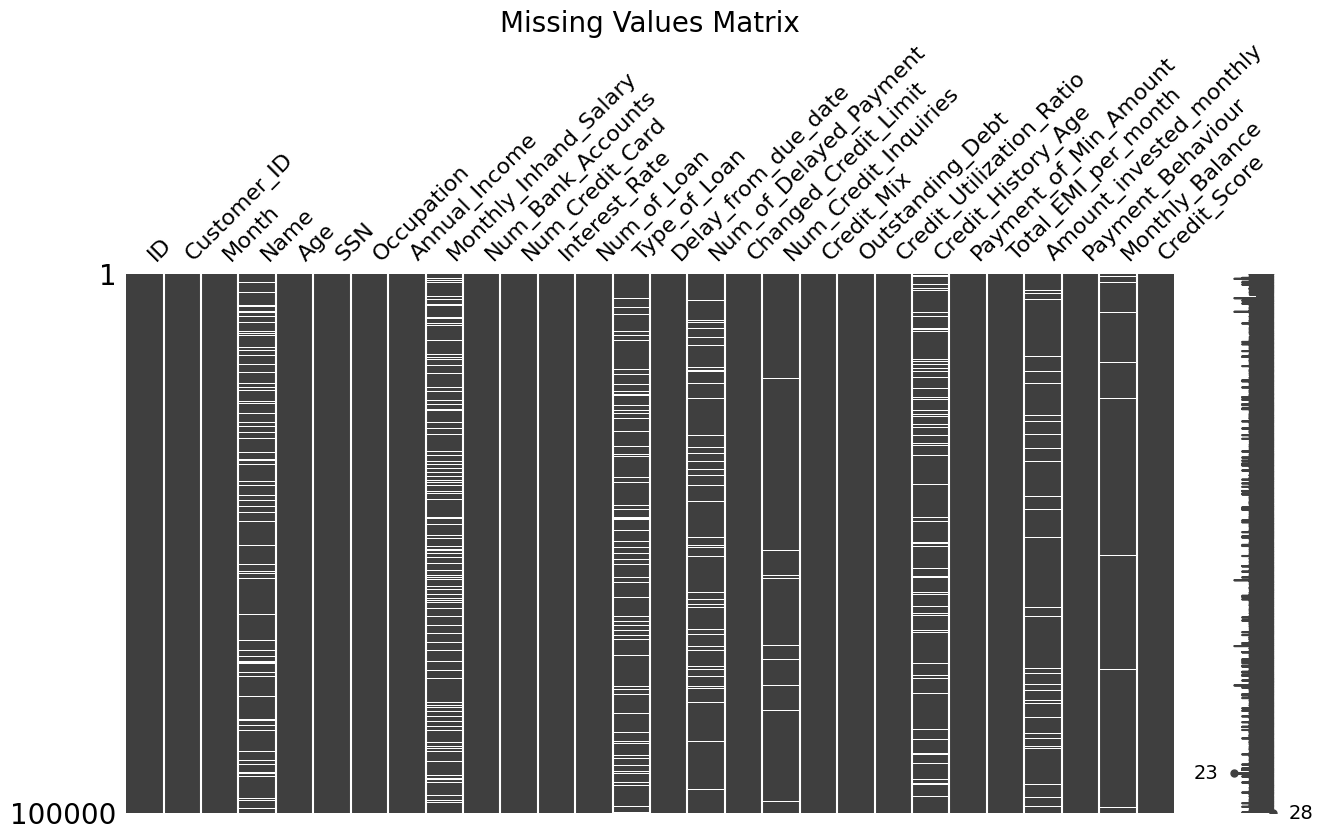

In [7]:
msno.matrix(df, figsize=(15, 7))
plt.title('Missing Values Matrix', fontsize=20)
plt.show()

In [10]:
display(df.head(20))

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Calculated_Monthly_Inhand_Salary
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good,1592.843333
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good,1592.843333
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good,1592.843333
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good,1592.843333
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good,1592.843333
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good,1592.843333
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674122349,Low_spent_Small_value_payments,244.5653167062043,Good,1592.843333
7,0x1609,CUS_0xd40,August,NaN,23,#F%$D@*&8,Scientist,19114.12,1824.843333,3,...,809.98,23.933795,NaN,No,49.574949,24.785216509052056,High_spent_Medium_value_payments,358.12416760938714,Standard,1592.843333
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard,2903.986667
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good,2903.986667


Now, let's address the missing `Monthly_Inhand_Salary` values by grouping by `Customer_ID`. We will fill the missing salaries for a customer with a non-missing salary value available for that same customer. After this, we will recheck the `df.info()` to see the improvement in data completeness.

In [12]:
df['Monthly_Inhand_Salary'] = df.groupby('Customer_ID')['Monthly_Inhand_Salary'].transform(lambda x: x.ffill().bfill())

df.info()
display(df.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   ID                                100000 non-null  object 
 1   Customer_ID                       100000 non-null  object 
 2   Month                             100000 non-null  object 
 3   Name                              90015 non-null   object 
 4   Age                               100000 non-null  int64  
 5   SSN                               100000 non-null  object 
 6   Occupation                        100000 non-null  object 
 7   Annual_Income                     100000 non-null  float64
 8   Monthly_Inhand_Salary             100000 non-null  float64
 9   Num_Bank_Accounts                 100000 non-null  int64  
 10  Num_Credit_Card                   100000 non-null  int64  
 11  Interest_Rate                     100000 non-null  in

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Calculated_Monthly_Inhand_Salary
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good,1592.843333
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good,1592.843333
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,1824.843333,3,...,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good,1592.843333
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good,1592.843333
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good,1592.843333
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good,1592.843333
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674122349,Low_spent_Small_value_payments,244.5653167062043,Good,1592.843333
7,0x1609,CUS_0xd40,August,NaN,23,#F%$D@*&8,Scientist,19114.12,1824.843333,3,...,809.98,23.933795,NaN,No,49.574949,24.785216509052056,High_spent_Medium_value_payments,358.12416760938714,Standard,1592.843333
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard,2903.986667
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good,2903.986667


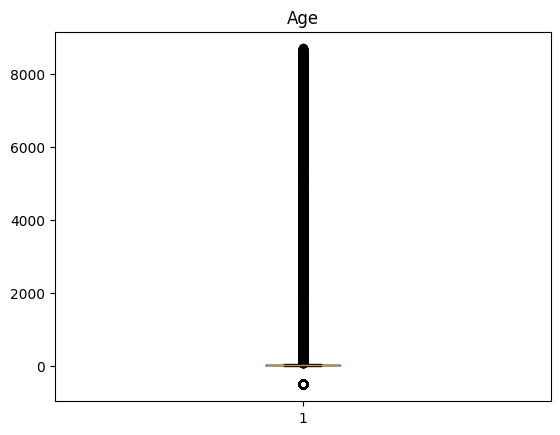

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.boxplot(df['Age'])
plt.title("Age")
plt.show()

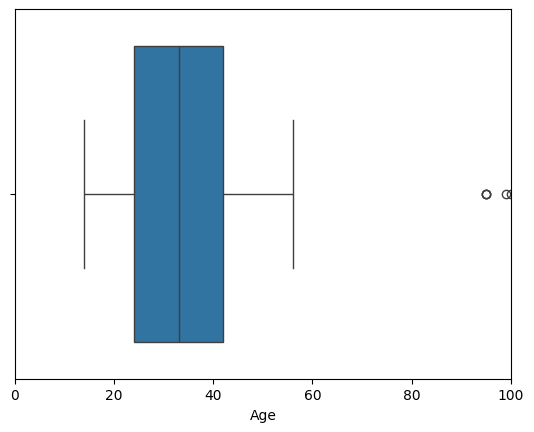

In [20]:
sns.boxplot(x=df["Age"])
plt.xlim(0, 100)
plt.show()

In [21]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'] = df['Age'].apply(lambda x: x if 0 <= x <= 90 else pd.NA)

df['Age'] = df.groupby('Customer_ID')['Age'].transform(lambda x: x.ffill().bfill())

print(df['Age'].describe())

/tmp/ipykernel_8599/163012099.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Age'] = df.groupby('Customer_ID')['Age'].transform(lambda x: x.ffill().bfill())


count    100000.000000
mean         33.309240
std          10.764996
min          14.000000
25%          24.000000
50%          33.000000
75%          42.000000
max          56.000000
Name: Age, dtype: float64


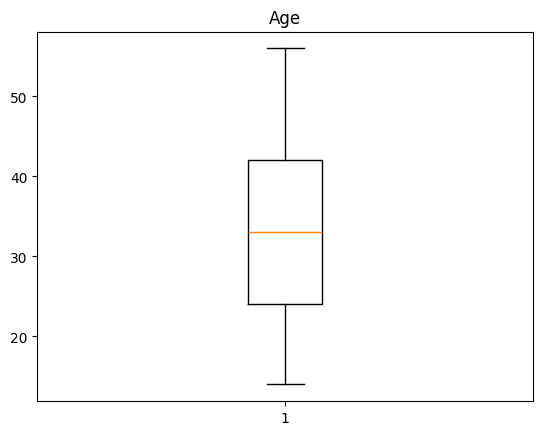

In [22]:
plt.boxplot(df['Age'])
plt.title("Age")
plt.show()

In [23]:
nan_age_count = df['Age'].isnull().sum()
print(f"{nan_age_count}")

0


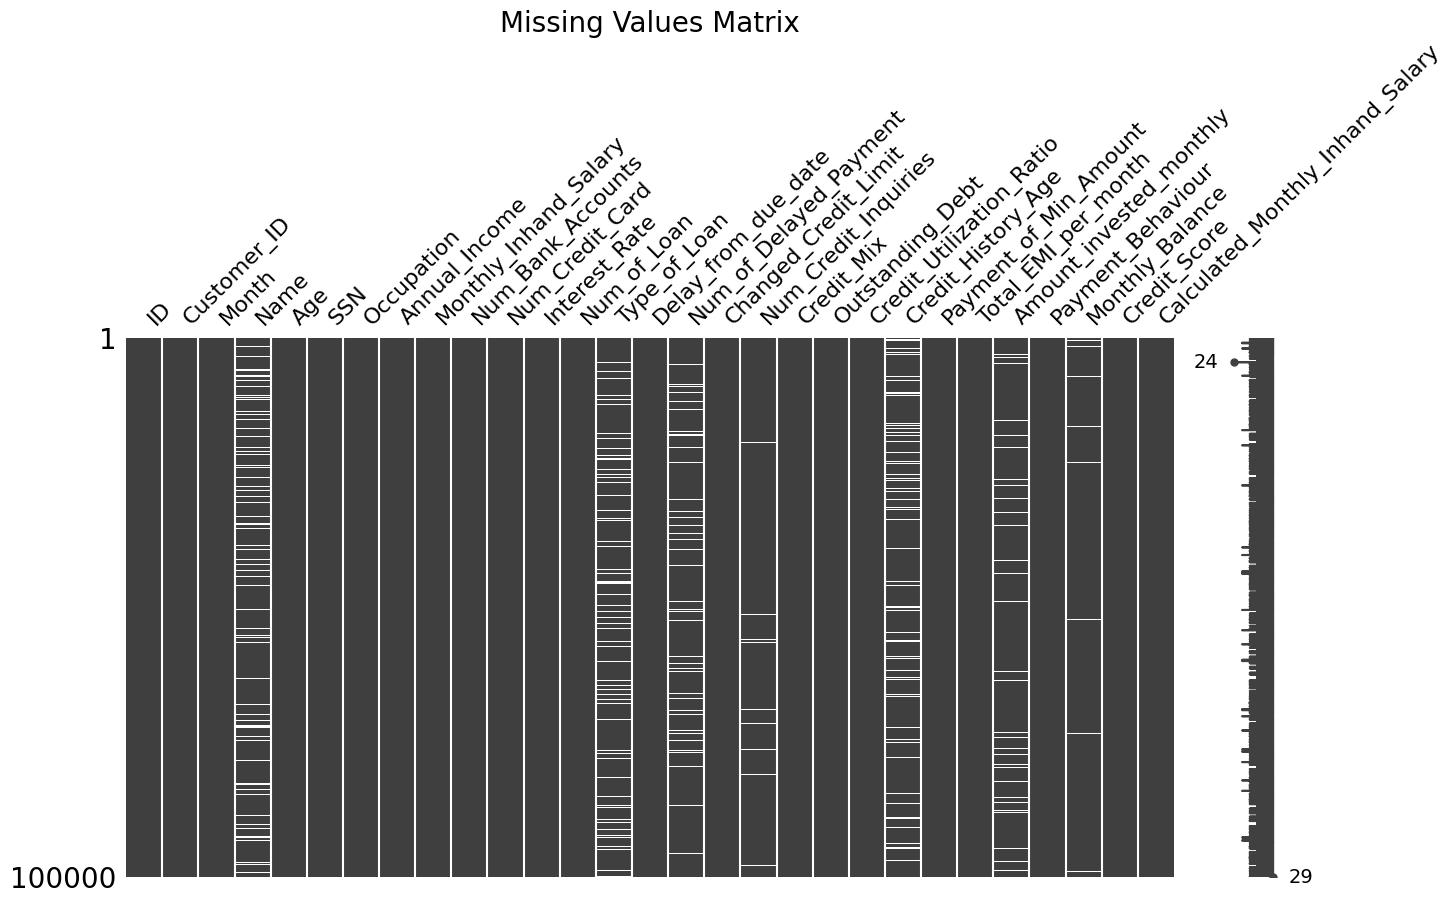

In [24]:
msno.matrix(df, figsize=(15, 7))
plt.title('Missing Values Matrix', fontsize=20)
plt.show()

In [27]:
pd.set_option('display.max_columns', None)
display(df.head(50))

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Calculated_Monthly_Inhand_Salary
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good,1592.843333
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good,1592.843333
2,0x1604,CUS_0xd40,March,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good,1592.843333
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good,1592.843333
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good,1592.843333
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",8,4,9.27,4.0,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good,1592.843333
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,8_,11.27,4.0,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674122349,Low_spent_Small_value_payments,244.5653167062043,Good,1592.843333
7,0x1609,CUS_0xd40,August,NaN,23,#F%$D@*&8,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,6,11.27,4.0,Good,809.98,23.933795,NaN,No,49.574949,24.785216509052056,High_spent_Medium_value_payments,358.12416760938714,Standard,1592.843333
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,3,4,5.42,2.0,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard,2903.986667
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,7,1,7.42,2.0,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good,2903.986667


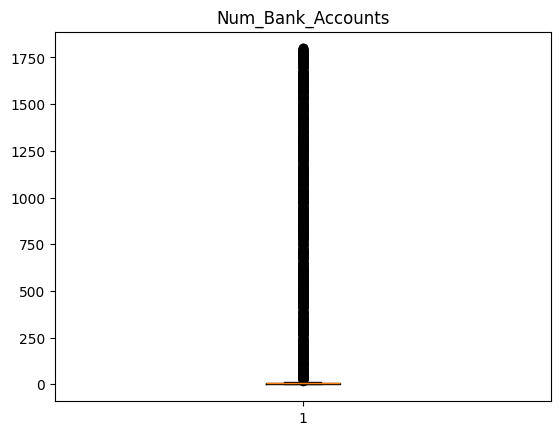

In [28]:
plt.boxplot(df['Num_Bank_Accounts'])
plt.title("Num_Bank_Accounts")
plt.show()

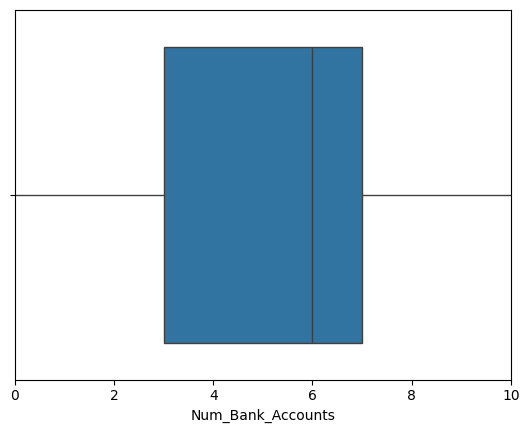

In [31]:
sns.boxplot(x=df["Num_Bank_Accounts"])
plt.xlim(0, 10)
plt.show()

In [35]:
negative_bank_accounts = df[df['Num_Bank_Accounts'] < 0]
print(negative_bank_accounts)

            ID Customer_ID     Month            Name  Age          SSN  \
30330   0xc7b8  CUS_0x4f2a     March       Margaretf   39  807-03-5415   
30331   0xc7b9  CUS_0x4f2a     April       Margaretf   40    #F%$D@*&8   
30332   0xc7ba  CUS_0x4f2a       May       Margaretf   40  807-03-5415   
30333   0xc7bb  CUS_0x4f2a      June       Margaretf   40  807-03-5415   
30334   0xc7bc  CUS_0x4f2a      July       Margaretf   40  807-03-5415   
30335   0xc7bd  CUS_0x4f2a    August       Margaretf   40  807-03-5415   
43689  0x115ff  CUS_0xa878  February  Douwe Miedemaz   54  300-54-4627   
43690  0x11600  CUS_0xa878     March  Douwe Miedemaz   54  300-54-4627   
43691  0x11601  CUS_0xa878     April  Douwe Miedemaz   54  300-54-4627   
43692  0x11602  CUS_0xa878       May  Douwe Miedemaz   54  300-54-4627   
43693  0x11603  CUS_0xa878      June  Douwe Miedemaz   54  300-54-4627   
43694  0x11604  CUS_0xa878      July  Douwe Miedemaz   54  300-54-4627   
43695  0x11605  CUS_0xa878    August  

In [36]:
print(f"{len(negative_bank_accounts)}")

21


In [38]:
df = df[df['Num_Bank_Accounts'] >= 0]

In [44]:
weird_bank_accounts = df[df['Num_Bank_Accounts'] > 10]
print(f"{len(weird_bank_accounts)}")

1324


In [49]:
import numpy as np
df.loc[df['Num_Bank_Accounts'] > 10, 'Num_Bank_Accounts'] = np.nan
df.loc[df['Num_Bank_Accounts'] < 0, 'Num_Bank_Accounts'] = np.nan

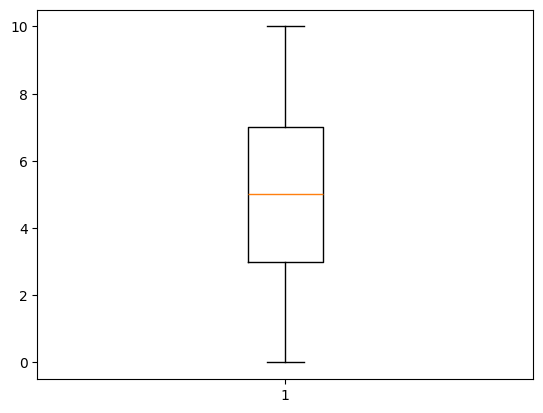

In [70]:
plt.boxplot(df['Num_Bank_Accounts'].dropna())
plt.show()

In [51]:
print(df['Num_Bank_Accounts'].describe())

count    98655.000000
mean         5.368466
std          2.592011
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: Num_Bank_Accounts, dtype: float64


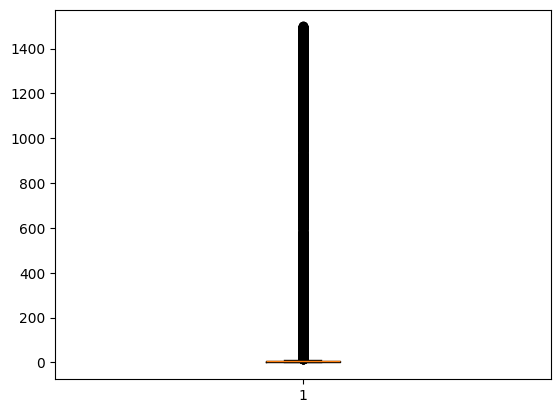

In [52]:
plt.boxplot(df['Num_Credit_Card'].dropna())
plt.show()

In [63]:
count = (df['Num_Credit_Card'] > 20).sum()
print(count)

2262


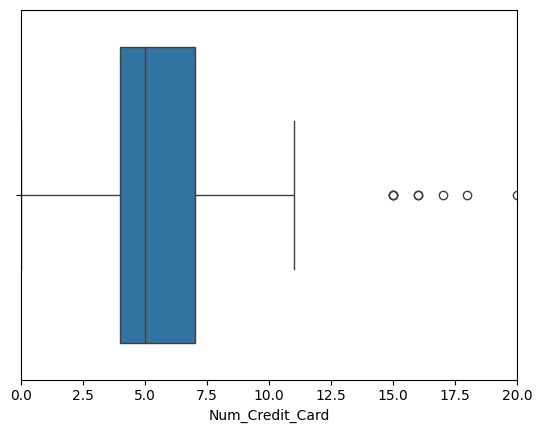

In [65]:
sns.boxplot(x=df["Num_Credit_Card"])
plt.xlim(0, 20)
plt.show()

In [68]:
df.loc[df['Num_Credit_Card'] > 13, 'Num_Credit_Card'] = np.nan

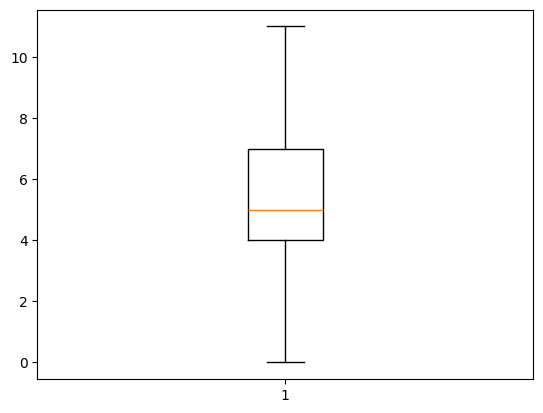

In [69]:
plt.boxplot(df['Num_Credit_Card'].dropna())
plt.show()

In [71]:
count = (df['Num_Credit_Card']).isnull().sum()
print(count)

2270


In [75]:
df['Num_Bank_Accounts'] = df.groupby('Customer_ID')['Num_Bank_Accounts'].transform(lambda x: x.ffill().bfill())
print(f"{df['Num_Bank_Accounts'].isnull().sum()}")

0


In [74]:
df['Num_Credit_Card'] = df.groupby('Customer_ID')['Num_Credit_Card'].transform(lambda x: x.ffill().bfill())
print(f"{df['Num_Credit_Card'].isnull().sum()}")

0


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99979 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ID                                99979 non-null  object 
 1   Customer_ID                       99979 non-null  object 
 2   Month                             99979 non-null  object 
 3   Name                              89997 non-null  object 
 4   Age                               99979 non-null  int64  
 5   SSN                               99979 non-null  object 
 6   Occupation                        99979 non-null  object 
 7   Annual_Income                     99979 non-null  float64
 8   Monthly_Inhand_Salary             99979 non-null  float64
 9   Num_Bank_Accounts                 99979 non-null  float64
 10  Num_Credit_Card                   99979 non-null  float64
 11  Interest_Rate                     99979 non-null  int64  
 12  Num_of_Lo